In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
from functools import reduce
from itertools import combinations
import pandas as pd
import collections

##### Dados. Começa com 10 ativos simulados: sorteia um retorno médio mensal pra cada, gera uma série de uns 60 meses com ruído, e calcula a matriz de covariância. Assim você não depende de baixar nada. Trocar por dados reais depois é só mudar a origem da matriz.

##### Representação. O indivíduo é o vetor de pesos, tipo [0.15, 0.0, 0.32, ...], um por ativo.

##### Função objetivo. O índice de Sharpe da carteira: retorno esperado sobre o desvio-padrão. Maximização.#

In [2]:
ativos = [i for i in range(10)]
periodos = [i for i in range(60)]

In [353]:
# df = pd.DataFrame(np.random.normal(0.01,0.11,(60,10)), index = periodos, columns=ativos)
# print(df.describe())
# for i in range(len(df.columns)):
#     if random.random() <0.5:
#         df[i] = df[i]*random.random()**2
# print(df.describe())

df = pd.read_csv('df_ativos_2025.csv').set_index('date')
colunas = df.columns
df = df.rename(columns={colunas[i]:i for i in range(len(colunas))})
df = df[[0,4,10,20,24,30,40,50,60,70]]

In [354]:
# individuos = [0.03,0.05,0.2,0.4]
media_ativos = df.mean()
cov = df.cov()
def fo(lista):
    pesos = np.array(lista)
    mi_x = (pesos*media_ativos).sum()
    dv_carteira =  np.sqrt(pesos.T @ cov @ pesos)   
    sharpe = mi_x/dv_carteira

    return sharpe

In [396]:
abs(random.gauss(0, 0.05))

0.03482715133127716

In [415]:
def ga(pop_tamanho, num_gen):

    # inicialização
    pop = []
    fit_history= []
    solutions_history= []

    best_solution = None
    best_fit = float('-inf')

    # preencher pop
    for p in range(pop_tamanho):
        p = list(np.random.dirichlet(np.ones(len(ativos)),size=1)[0])
        pop.append(p)

    for ngen in range(num_gen):

        # evaluation
        fitness_pop = [fo(p) for p in pop]
        # seleção
        pais = []
        for i in range(pop_tamanho):

            p0 = random.sample(range(len(pop)), k=3)
            max0 = max(p0, key = lambda p: fitness_pop[p])
            pais.append(pop[max0])

        # crossover
        offspring = []
        tamanho_max = len(pais[0])
        for i in range(pop_tamanho):
            n = random.randint(2,tamanho_max-2)
            n2 = random.randint(0,1)

            pai1 = random.choices(pais, k=2)[n2]
            pai2 = random.choices(pais, k=2)[n2]
            f = pai1[:n] + pai2[n:]
            # print(f)
            sum_f = sum(f)
            f_repair = [f[i]/sum_f for i in range(len(f))]
            offspring.append(f_repair)
        
        # mutation
        tx = 1/8
        for i in range(len(offspring)):
            if random.random() < tx:
                j_value = random.randint(0,len(offspring[i])-1)
                troca =  abs(random.gauss(0, 0.05))
                if offspring[i][j_value] < troca: 
                    offspring[i][j_value] = abs(offspring[i][j_value] - troca)
                else:
                    offspring[i][j_value] = offspring[i][j_value] + troca
            soma = sum(offspring[i])
            offspring[i] = [offspring[i][j]/soma for j in range(len(offspring[i]))]

        # elitism
        if best_solution is not None:
            offspring[0] = best_solution

        pop = offspring

        if pop:
            best_solution = max(pop, key=lambda p: fo(p))
            best_fit = fo(best_solution)
        fit_history.append(best_fit)
        solutions_history.append(best_solution)

        print(f"Geração {ngen+1}, Best solution: {best_solution}, Best Fitness: {best_fit}")
    return solutions_history

In [416]:
sols = ga(700,200)

Geração 1, Best solution: [np.float64(0.05307967638134269), np.float64(0.041462624574796644), np.float64(0.024389536173393844), np.float64(0.42629472865772056), np.float64(0.013156002055283434), np.float64(0.01081958110059473), np.float64(0.24779397419360874), np.float64(0.013557857066940862), np.float64(0.16639451454403342), np.float64(0.003051505252284855)], Best Fitness: 0.19828045773353095
Geração 2, Best solution: [np.float64(0.410105252238224), np.float64(0.006131446374808976), np.float64(0.0070262439411464695), np.float64(0.25931230859583954), np.float64(0.025464381896339497), np.float64(0.01687058926558774), np.float64(0.22954794821364424), np.float64(0.01151395372384382), np.float64(0.03255031482842253), np.float64(0.0014775609221431907)], Best Fitness: 0.23313243635933031
Geração 3, Best solution: [np.float64(0.23107166980347946), np.float64(0.003454731546121728), np.float64(0.035816314443420545), np.float64(0.5038483142745183), np.float64(0.010708932732591114), np.float64(0.

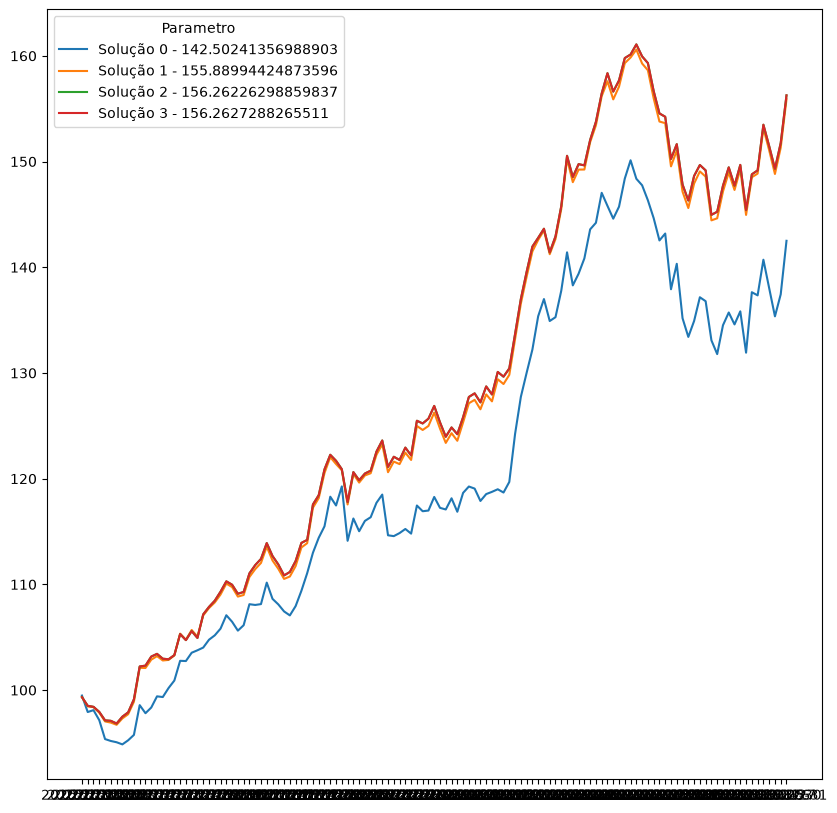

In [418]:
fig, ax = plt.subplots(figsize=(10,10))

for i, sol in enumerate([sols[0],sols[20],sols[100],sols[-1]]):
    carteira = df@sol
    acumulado = carteira+1
    ac = acumulado.cumprod()*100
    # Adicionado o parâmetro 'label' aqui:
    ax.plot(ac.index, ac.values, label=f"Solução {i} - {ac.values[-1]}")
ax.legend(title="Parametro")
plt.show()